In [1]:
import scipy as sp
import numpy as np
import pandas as pd
import pickle
import os
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.notebook import tqdm

# pd.set_option('display.max_rows', 50)

In [2]:
folder_path = "./table_results/"
files = [folder_path + entry.name for entry in os.scandir(folder_path) if (entry.is_file() and "swept2" in entry.name)]
print(files)

['./table_results/results_icml_2_2_swept2.pkl', './table_results/results_icml_4_30_swept2.pkl', './table_results/results_icml_2_10_swept2.pkl', './table_results/results_icml_2_30_swept2.pkl', './table_results/results_icml_2_5_swept2.pkl', './table_results/results_icml_1_20_swept2.pkl', './table_results/results_icml_4_30_swept2_special.pkl', './table_results/results_icml_1_30_swept2.pkl', './table_results/results_icml_4_10_swept2_special.pkl', './table_results/results_icml_1_10_swept2.pkl', './table_results/results_icml_1_30_swept2_special.pkl', './table_results/results_icml_2_30_swept2_special.pkl', './table_results/results_icml_2_10_swept2_special.pkl', './table_results/results_icml_1_2_swept2_special.pkl', './table_results/results_icml_4_5_swept2.pkl', './table_results/results_icml_4_2_swept2.pkl', './table_results/results_icml_2_20_swept2.pkl', './table_results/results_icml_1_5_swept2_special.pkl', './table_results/results_icml_1_10_swept2_special.pkl', './table_results/results_icml

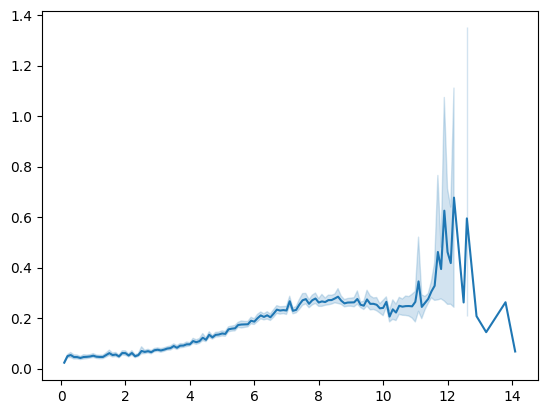

In [3]:
with open(files[0], "rb") as f:
    results = pickle.load(f)

mse = np.mean((results["0 0 rl"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
abs_value = np.mean(np.abs(results["0 0 rl"]["value"]), axis=1)

sns.lineplot(x=np.round(abs_value, 1), y=mse)
plt.show()

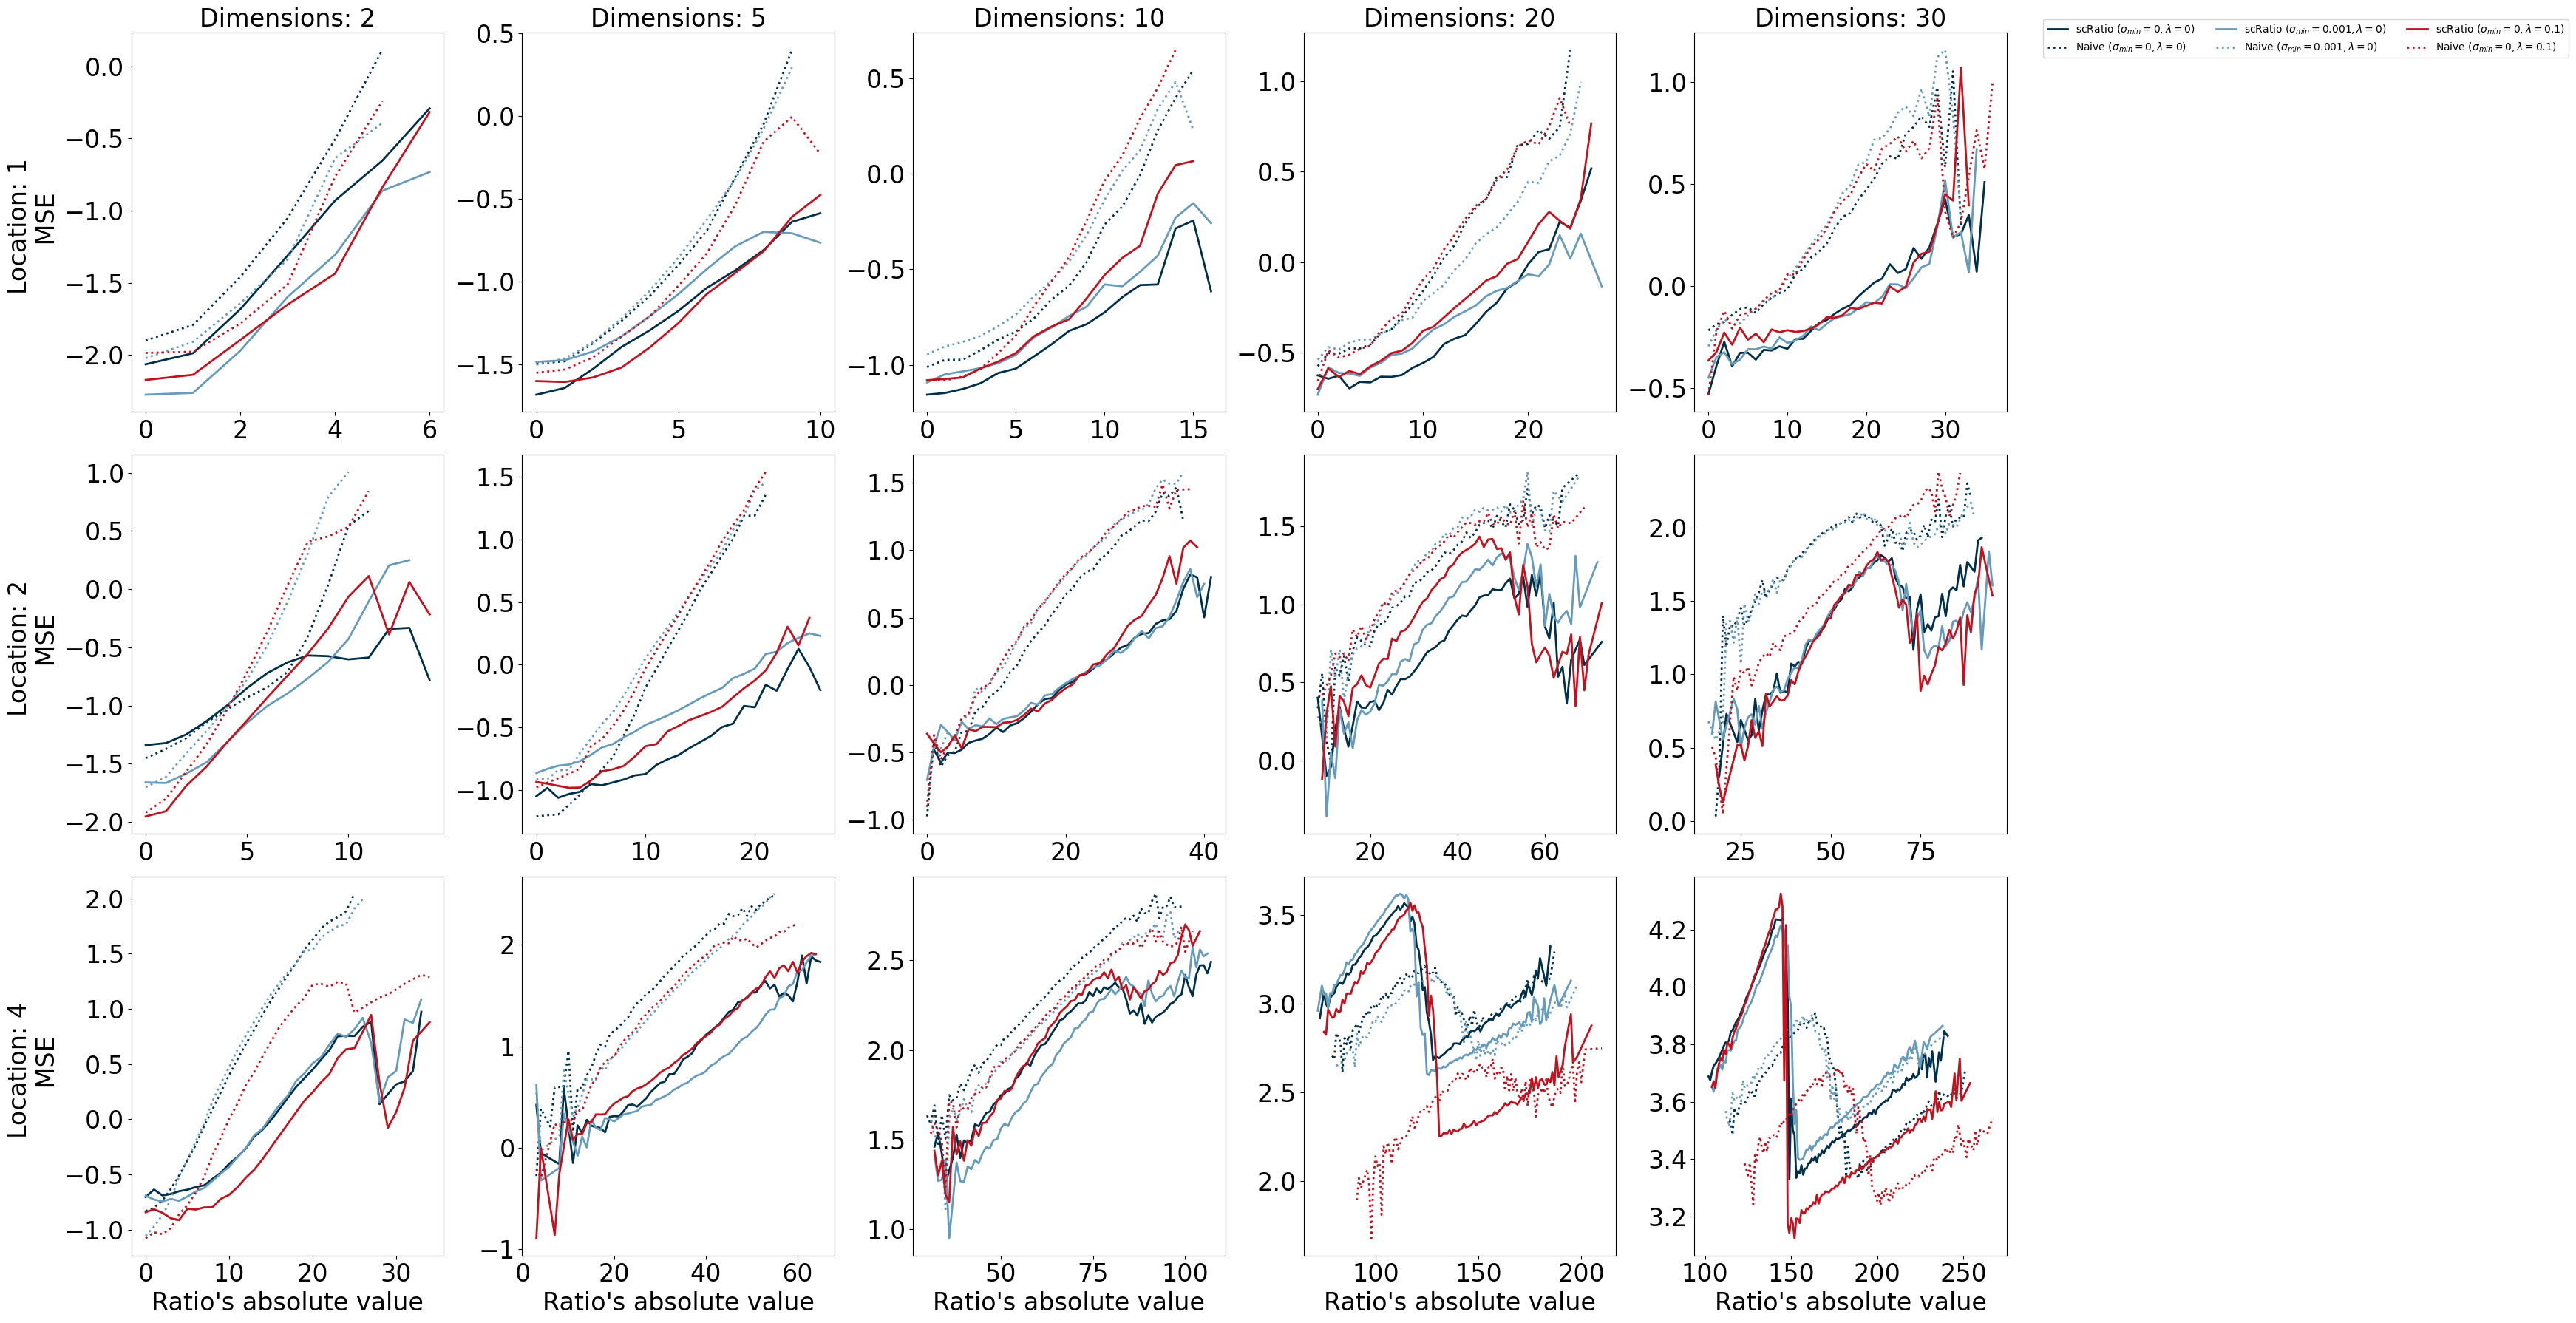

In [6]:
fig, axes = plt.subplots(3, 5, figsize=(7*5, 18))

colors = {"s": "#C1121F", "p": "#669BBC", "d": "#003049"}
label_suffixes = {
    "s": rf" $(\sigma_{{min}} = 0, \lambda = 0.1)$",
    "p": rf" $(\sigma_{{min}} = 0.001, \lambda = 0)$",
    "d": rf" $(\sigma_{{min}} = 0, \lambda = 0)$"
}

def plot_data(axes, value, mse, label, color, style):
    value = np.round(value)
    unqs = np.unique(value)

    grouped = []
    for unq in unqs:
        grouped.append(np.mean(mse[value == unq]))
    
    axes.plot(
        unqs,
        np.log10(grouped), 
        # marker='o',
        label=label,
        linestyle=style,
        linewidth=2,
        color=color
    )

for i, l in enumerate([1, 2, 4]):
    for j, d in enumerate([2, 5, 10, 20, 30]):
        with open(f'./table_results/results_icml_{l}_{d}_swept2.pkl', "rb") as f:
            results = pickle.load(f)

        d_rl_mse = np.mean((results["0 0 rl"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
        d_rl_abs_value = np.mean(np.abs(results["0 0 rl"]["value"]), axis=1)

        d_naive_mse = np.mean((results["0 0 naive"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
        d_naive_abs_value = np.mean(np.abs(results["0 0 naive"]["value"]), axis=1)

        p_rl_mse = np.mean((results["0.001 0 rl"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
        p_rl_abs_value = np.mean(np.abs(results["0.001 0 rl"]["value"]), axis=1)

        p_naive_mse = np.mean((results["0.001 0 naive"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
        p_naive_abs_value = np.mean(np.abs(results["0.001 0 naive"]["value"]), axis=1)

        with open(f'./table_results/results_icml_{l}_{d}_swept2_special.pkl', "rb") as f:
            results = pickle.load(f)
        
        s_rl_mse = np.mean((results["0 0.1 rl"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
        s_rl_abs_value = np.mean(np.abs(results["0 0.1 rl"]["value"]), axis=1)

        s_naive_mse = np.mean((results["0 0.1 naive"]["value"] - results["- - true"]["value"][:, :1]) ** 2, axis=1)
        s_naive_abs_value = np.mean(np.abs(results["0 0.1 naive"]["value"]), axis=1)

        plot_data(
            axes=axes[i, j],
            mse=d_rl_mse,
            value=d_rl_abs_value,
            label="scRatio" + label_suffixes["d"],
            color=colors["d"],
            style="-"
        )

        plot_data(
            axes=axes[i, j],
            mse=d_naive_mse,
            value=d_naive_abs_value,
            label="Naive" + label_suffixes["d"],
            color=colors["d"],
            style=":"
        )

        plot_data(
            axes=axes[i, j],
            mse=p_rl_mse,
            value=p_rl_abs_value,
            label="scRatio" + label_suffixes["p"],
            color=colors["p"],
            style="-"
        )

        plot_data(
            axes=axes[i, j],
            mse=p_naive_mse,
            value=p_naive_abs_value,
            label="Naive" + label_suffixes["p"],
            color=colors["p"],
            style=":"
        )

        plot_data(
            axes=axes[i, j],
            mse=s_rl_mse,
            value=s_rl_abs_value,
            label="scRatio" + label_suffixes["s"],
            color=colors["s"],
            style="-"
        )

        plot_data(
            axes=axes[i, j],
            mse=s_naive_mse,
            value=s_naive_abs_value,
            label="Naive" + label_suffixes["s"],
            color=colors["s"],
            style=":"
        )

        if i == 0:
            axes[i, j].set_title(f"Dimensions: {d}", fontsize=24)
        if i == 2:
            axes[i, j].set_xlabel("Ratio's absolute value", fontsize=24)
        if j == 0:
            axes[i, j].set_ylabel(f'Location: {l} \n MSE', fontsize=24)
        axes[i, j].grid(visible=False)
        axes[i, j].tick_params(labelsize=24)
        if i == 0 and j == 4:
            axes[i, j].legend(bbox_to_anchor=(1.1, 1.05), ncol=3)

plt.tight_layout()
plt.savefig("saved_plots/legend.svg", dpi=300, bbox_inches="tight")
plt.show()